In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA

In [2]:
df = pd.read_csv("C:\\Users\\priya\\OneDrive\\Documents\\DS_Projects\\AmazonMusic\\single_genre_artists.csv")

print("Shape:", df.shape)
df.head()


Shape: (95837, 23)


,id_songs,name_song,popularity_songs,duration_ms,explicit,id_artists,release_date,danceability,energy,key,...,acousticness,instrumentalness,liveness,valence,tempo,time_signature,followers,genres,name_artists,popularity_artists
0,0IA0Hju8CAgYfV1hwhidBH,La Java,0,161427,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.563,0.184,4,...,0.993,0.000016,0.325,0.654,133.088,3,5078.0,['vintage chanson'],Mistinguett,22
1,1b8HZQCqcqwbzlA1jRTp6E,En Douce,0,223440,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.427,0.180,10,...,0.989,0.000000,0.128,0.431,78.459,3,5078.0,['vintage chanson'],Mistinguett,22
2,5d5gQxHwYovxR5pqETOIAa,J'en Ai Marre,0,208267,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.511,0.206,0,...,0.995,0.000000,0.418,0.481,70.443,4,5078.0,['vintage chanson'],Mistinguett,22
3,1EO65UEEPfy7CR0NK2sDxy,Ils n'ont pas ca,0,161933,0,4AxgXfD7ISvJSTObqm4aIE,1924,0.676,0.467,9,...,0.991,0.000000,0.219,0.726,129.775,4,5078.0,['vintage chanson'],Mistinguett,22
4,6a58gXSgqbIsXUhVZ6ZJqe,La belote,0,167973,0,4AxgXfD7ISvJSTObqm4aIE,1924,0.650,0.298,9,...,0.991,0.000000,0.373,0.844,75.950,4,5078.0,['vintage chanson'],Mistinguett,22


In [3]:
df.info()
df.describe()

# Missing values
print("Missing Values:\n", df.isnull().sum())

# Duplicate rows
print("Duplicates:", df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95837 entries, 0 to 95836
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_songs            95837 non-null  object 
 1   name_song           95837 non-null  object 
 2   popularity_songs    95837 non-null  int64  
 3   duration_ms         95837 non-null  int64  
 4   explicit            95837 non-null  int64  
 5   id_artists          95837 non-null  object 
 6   release_date        95837 non-null  object 
 7   danceability        95837 non-null  float64
 8   energy              95837 non-null  float64
 9   key                 95837 non-null  int64  
 10  loudness            95837 non-null  float64
 11  mode                95837 non-null  int64  
 12  speechiness         95837 non-null  float64
 13  acousticness        95837 non-null  float64
 14  instrumentalness    95837 non-null  float64
 15  liveness            95837 non-null  float64
 16  vale

In [4]:
# Remove duplicates
df = df.drop_duplicates()

# Drop unnecessary columns
df_clean = df.drop(columns=["track_name", "artist_name", "track_id"], errors='ignore')

df_clean.head()

,id_songs,name_song,popularity_songs,duration_ms,explicit,id_artists,release_date,danceability,energy,key,...,acousticness,instrumentalness,liveness,valence,tempo,time_signature,followers,genres,name_artists,popularity_artists
0,0IA0Hju8CAgYfV1hwhidBH,La Java,0,161427,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.563,0.184,4,...,0.993,0.000016,0.325,0.654,133.088,3,5078.0,['vintage chanson'],Mistinguett,22
1,1b8HZQCqcqwbzlA1jRTp6E,En Douce,0,223440,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.427,0.180,10,...,0.989,0.000000,0.128,0.431,78.459,3,5078.0,['vintage chanson'],Mistinguett,22
2,5d5gQxHwYovxR5pqETOIAa,J'en Ai Marre,0,208267,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.511,0.206,0,...,0.995,0.000000,0.418,0.481,70.443,4,5078.0,['vintage chanson'],Mistinguett,22
3,1EO65UEEPfy7CR0NK2sDxy,Ils n'ont pas ca,0,161933,0,4AxgXfD7ISvJSTObqm4aIE,1924,0.676,0.467,9,...,0.991,0.000000,0.219,0.726,129.775,4,5078.0,['vintage chanson'],Mistinguett,22
4,6a58gXSgqbIsXUhVZ6ZJqe,La belote,0,167973,0,4AxgXfD7ISvJSTObqm4aIE,1924,0.650,0.298,9,...,0.991,0.000000,0.373,0.844,75.950,4,5078.0,['vintage chanson'],Mistinguett,22


In [5]:
features = [
    'danceability', 'energy', 'loudness', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness',
    'valence', 'tempo', 'duration_ms'
]

df_model = df_clean[features]
df_model.head()

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,0.563,0.184,-13.757,0.0512,0.993,0.000016,0.325,0.654,133.088,161427
1,0.427,0.180,-15.375,0.0670,0.989,0.000000,0.128,0.431,78.459,223440
2,0.511,0.206,-15.514,0.0592,0.995,0.000000,0.418,0.481,70.443,208267
3,0.676,0.467,-12.393,0.1650,0.991,0.000000,0.219,0.726,129.775,161933
4,0.650,0.298,-13.806,0.1380,0.991,0.000000,0.373,0.844,75.950,167973


In [7]:
#----Feature Scaling-----
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_model)

scaled_data[:5]

array([[-0.15347598, -1.51112816, -0.75790895, -0.42710882,  1.61618723,
        -0.35333823,  0.53858362,  0.32128698,  0.51500516, -0.40173462],
       [-1.02851842, -1.52805562, -1.09862851, -0.36974088,  1.60408122,
        -0.35340491, -0.52153664, -0.57745518, -1.2944868 ,  0.12490637],
       [-0.48805103, -1.41802711, -1.12789922, -0.39806176,  1.62224024,
        -0.35340491,  1.03904648, -0.37594348, -1.56000306, -0.00394925],
       [ 0.57358134, -0.31351008, -0.4706769 , -0.01391443,  1.61013423,
        -0.35340491, -0.03183642,  0.61146382,  0.40526772, -0.39743745],
       [ 0.40629381, -1.02869543, -0.76822741, -0.11194825,  1.61013423,
        -0.35340491,  0.79688703,  1.08703142, -1.37759312, -0.34614318]])

In [18]:
# Drop non-numeric columns automatically
df_model = df.select_dtypes(include=['number'])

# Optional: show what was removed
non_numeric = df.select_dtypes(exclude=['number']).columns.tolist()
st.write("Removed non-numeric columns:", non_numeric)

NameError: name 'st' is not defined

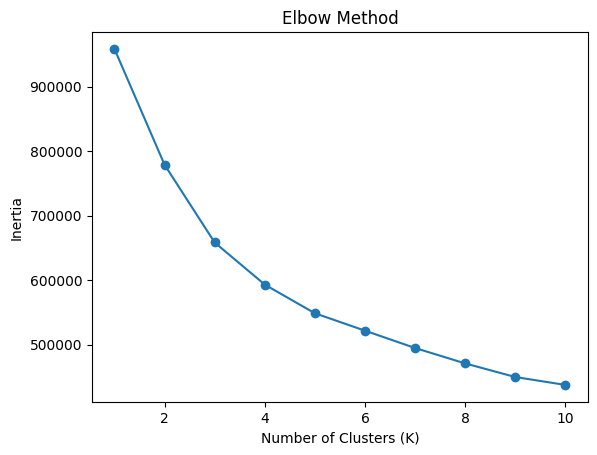

In [ ]:
#----Elbow Method to find optimal K-----
inertia = []

K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

plt.figure()
plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.show()

In [ ]:
#---Silhouette Score
k = 4  # Choose based on elbow

kmeans = KMeans(n_clusters=k, random_state=42)
labels = kmeans.fit_predict(scaled_data)

sil_score = silhouette_score(scaled_data, labels)
print("Silhouette Score:", sil_score)

Silhouette Score: 0.23106641264473857


In [10]:
df_clean['Cluster'] = labels

df_clean.head()

,id_songs,name_song,popularity_songs,duration_ms,explicit,id_artists,release_date,danceability,energy,key,...,instrumentalness,liveness,valence,tempo,time_signature,followers,genres,name_artists,popularity_artists,Cluster
0,0IA0Hju8CAgYfV1hwhidBH,La Java,0,161427,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.563,0.184,4,...,0.000016,0.325,0.654,133.088,3,5078.0,['vintage chanson'],Mistinguett,22,3
1,1b8HZQCqcqwbzlA1jRTp6E,En Douce,0,223440,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.427,0.180,10,...,0.000000,0.128,0.431,78.459,3,5078.0,['vintage chanson'],Mistinguett,22,3
2,5d5gQxHwYovxR5pqETOIAa,J'en Ai Marre,0,208267,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.511,0.206,0,...,0.000000,0.418,0.481,70.443,4,5078.0,['vintage chanson'],Mistinguett,22,3
3,1EO65UEEPfy7CR0NK2sDxy,Ils n'ont pas ca,0,161933,0,4AxgXfD7ISvJSTObqm4aIE,1924,0.676,0.467,9,...,0.000000,0.219,0.726,129.775,4,5078.0,['vintage chanson'],Mistinguett,22,3
4,6a58gXSgqbIsXUhVZ6ZJqe,La belote,0,167973,0,4AxgXfD7ISvJSTObqm4aIE,1924,0.650,0.298,9,...,0.000000,0.373,0.844,75.950,4,5078.0,['vintage chanson'],Mistinguett,22,3


In [11]:
db_score = davies_bouldin_score(scaled_data, labels)

print("Davies-Bouldin Index:", db_score)

Davies-Bouldin Index: 1.5296828507168276


In [12]:
cluster_summary = df_clean.groupby("Cluster")[features].mean()

cluster_summary

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
Cluster,,,,,,,,,,
0,0.485341,0.415775,-13.954724,0.059929,0.646652,0.810613,0.188557,0.449986,114.301014,231386.462428
1,0.634711,0.707636,-7.416184,0.077040,0.242192,0.021039,0.201125,0.685616,125.294702,224649.058878
2,0.664340,0.466488,-13.385665,0.834554,0.585597,0.000975,0.435223,0.583509,100.336080,96913.082601
3,0.505186,0.341825,-12.120023,0.060990,0.699190,0.017446,0.183097,0.426877,113.401800,224876.823023


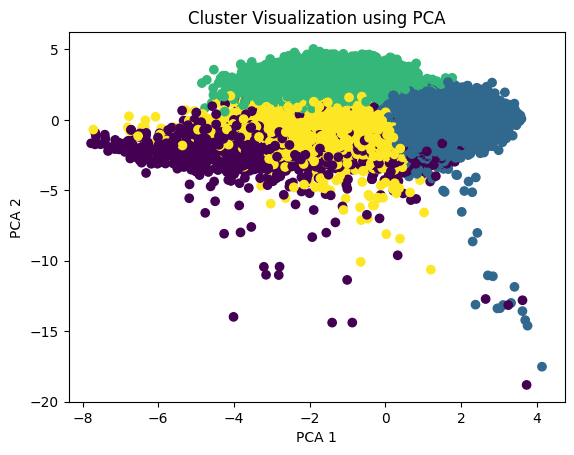

In [13]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

plt.figure()
plt.scatter(pca_data[:, 0], pca_data[:, 1], c=labels)
plt.title("Cluster Visualization using PCA")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

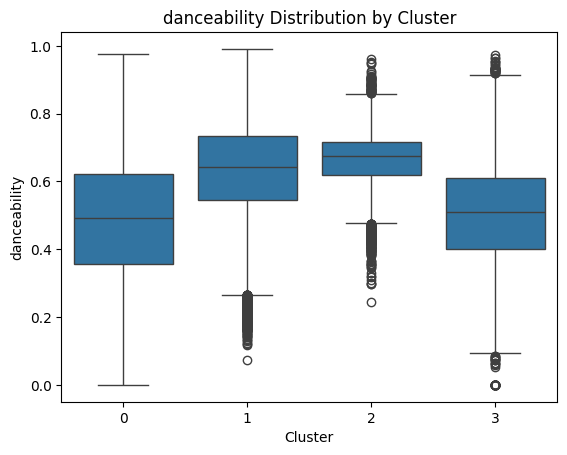

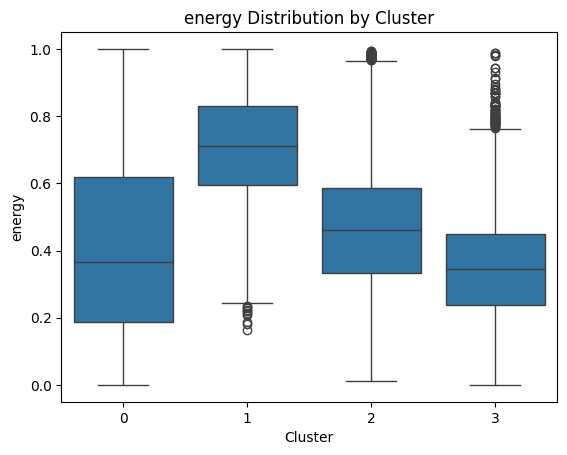

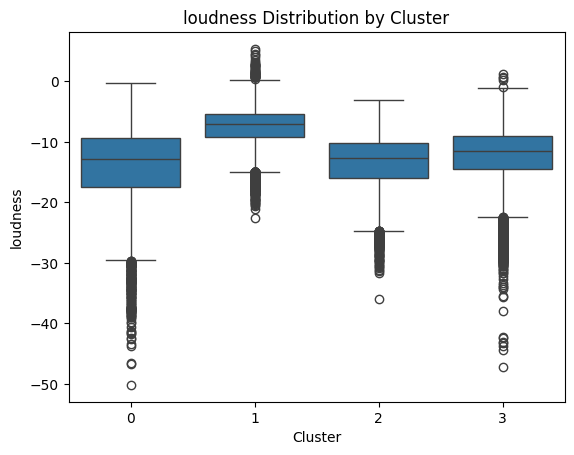

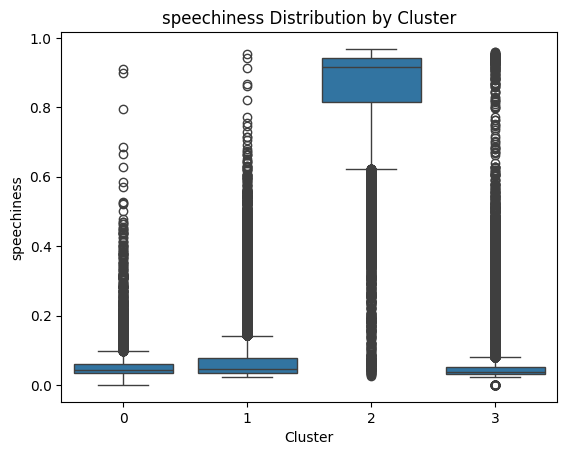

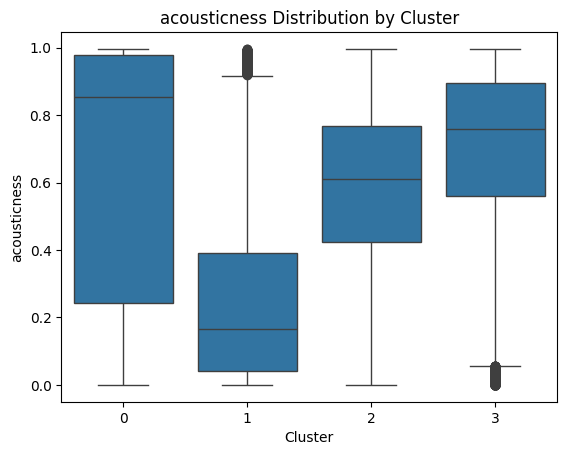

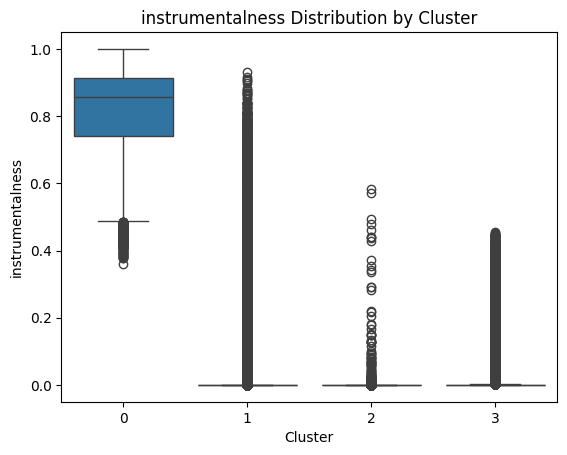

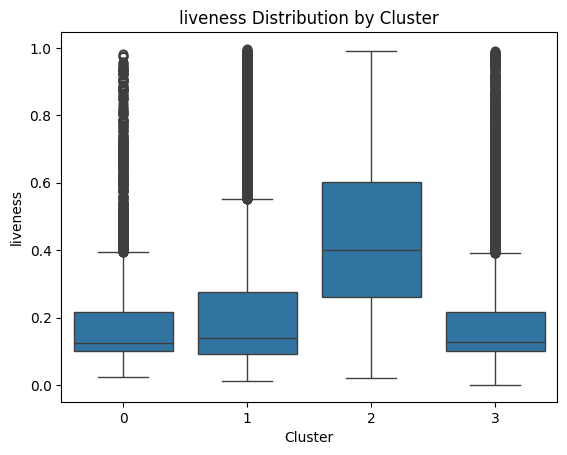

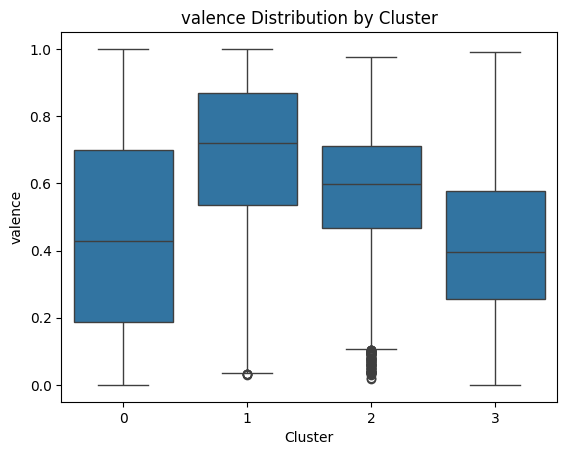

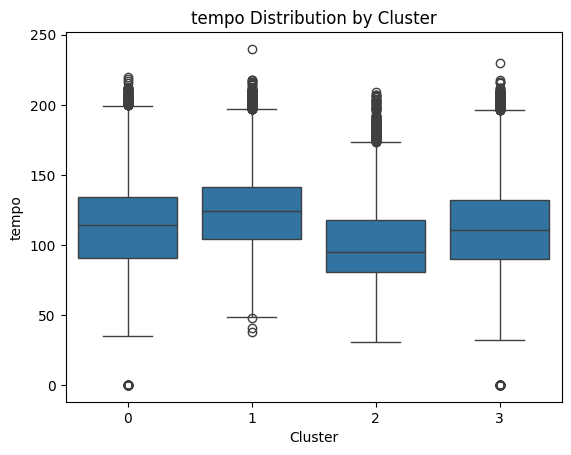

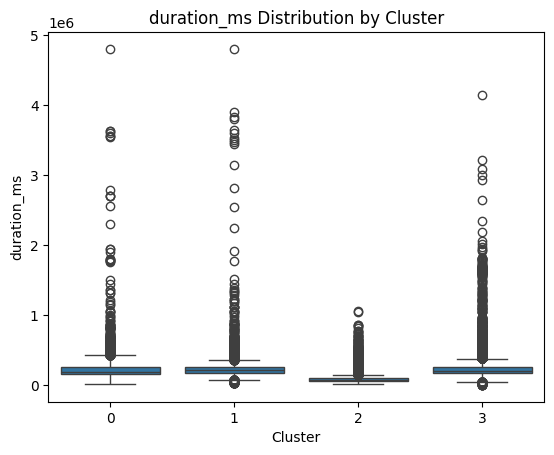

In [14]:
for feature in features:
    plt.figure()
    sns.boxplot(x='Cluster', y=feature, data=df_clean)
    plt.title(f"{feature} Distribution by Cluster")
    plt.show()

Cluster 0 → High energy + danceability → Party Songs
Cluster 1 → High acousticness → Chill Songs
Cluster 2 → High instrumentalness → Instrumental
Cluster 3 → Balanced → Pop

In [15]:
df_clean.to_csv("clustered_amazon_music.csv", index=False)

In [16]:
print("Explained Variance:", pca.explained_variance_ratio_)

Explained Variance: [0.27079553 0.18821441]


In [17]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=1.5, min_samples=5)
db_labels = dbscan.fit_predict(scaled_data)

print("DBSCAN unique clusters:", set(db_labels))

DBSCAN unique clusters: {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(-1)}
